In [13]:
import random, json, numpy as np, networkx as nx
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
import pandas as pd
import os

In [2]:
N         = 10_000   # population
I_0       = 10       # initially infectious
p_expose  = 0.40     # P(S→E) per infectious contact
p_infect  = 0.15     # P(E→I) per step
p_recover = 0.05     # P(I→R) per step
n_contacts = 3       # contacts each infectious person makes per step
k         = 6        # WS mean degree (even)
beta_ws   = 0.05     # WS rewiring probability
T         = 300      # max time steps
SEED      = 42
OUTPUT_DIR = "graph_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
S, E, I, R = 0, 1, 2, 3
COLORS = {S: '#4C9BE8', E: '#F5A623', I: '#E84C4C', R: '#6DBE6D'}
LABELS = {S: 'Susceptible', E: 'Exposed', I: 'Infectious', R: 'Recovered'}
 
G = nx.watts_strogatz_graph(N, k, beta_ws, seed=SEED)
 
rng    = random.Random(SEED)
states = np.zeros(N, dtype=np.int8)
for node in rng.sample(range(N), I_0):
    states[node] = I

Layout computed.


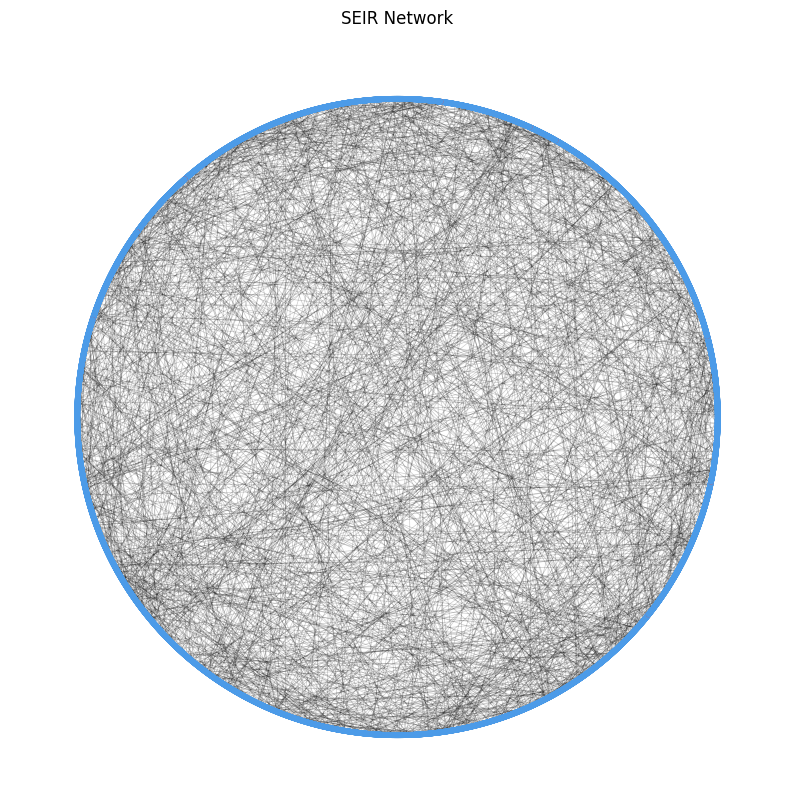

In [15]:
pos = nx.circular_layout(G)
print("Layout computed.")

# Node colors from states
node_colors = [COLORS[states[node]] for node in G.nodes()]

plt.figure(figsize=(10, 10))
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2,
    width=0.5
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=10
)

plt.title("SEIR Network")
plt.axis("off")
plt.savefig(f'{OUTPUT_DIR}/ws_graph.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
def step(states):
    nxt = states.copy()
    for node in np.where(states == I)[0]:
        neighbors = list(G.neighbors(node))
        contacts  = rng.choices(neighbors, k=min(n_contacts, len(neighbors)))
        for nb in contacts:
            if states[nb] == S and rng.random() < p_expose:
                nxt[nb] = E
    for node in np.where(states == E)[0]:
        if rng.random() < p_infect:  nxt[node] = I
    for node in np.where(states == I)[0]:
        if rng.random() < p_recover: nxt[node] = R
    return nxt

In [18]:
def step(states):
    nxt = states.copy()
    for node in np.where(states == I)[0]:
        neighbors = list(G.neighbors(node))
        contacts  = rng.choices(neighbors, k=min(n_contacts, len(neighbors)))
        for nb in contacts:
            if states[nb] == S and rng.random() < p_expose:
                nxt[nb] = E
    for node in np.where(states == E)[0]:
        if rng.random() < p_infect:  nxt[node] = I
    for node in np.where(states == I)[0]:
        if rng.random() < p_recover: nxt[node] = R
    return nxt

history = [states.copy()]
counts  = {c: [int(np.sum(states == v))] for c, v in zip('SEIR', [S, E, I, R])}
 
for t in range(1, T + 1):
    states = step(states)
    history.append(states.copy())
    for c, v in zip('SEIR', [S, E, I, R]):
        counts[c].append(int(np.sum(states == v)))
    if counts['E'][-1] == counts['I'][-1] == 0:
        print(f'Epidemic ended at t={t}'); break
 
T_end = len(counts['S']) - 1
print(f"Peak I: {max(counts['I']):,} at t={counts['I'].index(max(counts['I']))} | "
      f"Attack rate: {counts['R'][-1]/N*100:.1f}%")

Epidemic ended at t=247
Peak I: 2,960 at t=98 | Attack rate: 100.0%


In [19]:
nx.write_gexf(G, f'{OUTPUT_DIR}/graph.gexf')
 
params = dict(N=N, I_0=I_0, p_expose=p_expose, p_infect=p_infect,
              p_recover=p_recover, n_contacts=n_contacts,
              k=k, beta_ws=beta_ws, T=T, SEED=SEED)
with open(f'{OUTPUT_DIR}/params.json', 'w') as f:
    json.dump(params, f, indent=2)
 
df = pd.DataFrame({'t': range(T_end + 1), **counts})
df.to_csv(f'{OUTPUT_DIR}/seir_counts.csv', index=False)
 
print("Saved: graph.gexf, params.json, seir_counts.csv")

Saved: graph.gexf, params.json, seir_counts.csv


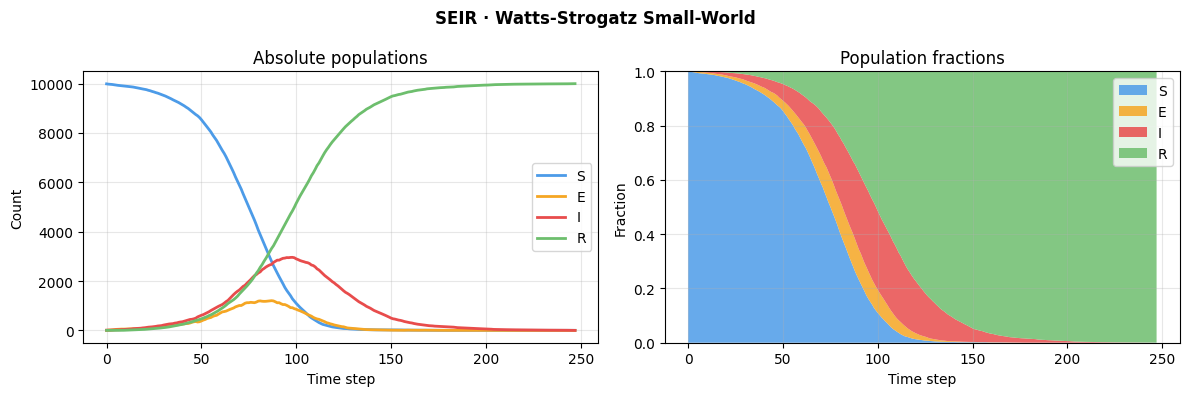

In [20]:
time = np.arange(T_end + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('SEIR · Watts-Strogatz Small-World', fontweight='bold')
 
for c, v in zip('SEIR', [S, E, I, R]):
    ax1.plot(time, counts[c], label=c, color=COLORS[v], lw=2)
ax1.set(xlabel='Time step', ylabel='Count', title='Absolute populations')
ax1.legend(); ax1.grid(alpha=.3)
 
fracs = [np.array(counts[c]) / N for c in 'SEIR']
ax2.stackplot(time, *fracs, labels=list('SEIR'),
              colors=[COLORS[v] for v in [S, E, I, R]], alpha=.85)
ax2.set(xlabel='Time step', ylabel='Fraction', title='Population fractions', ylim=(0, 1))
ax2.legend(loc='upper right'); ax2.grid(alpha=.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/seir_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Computing layout…


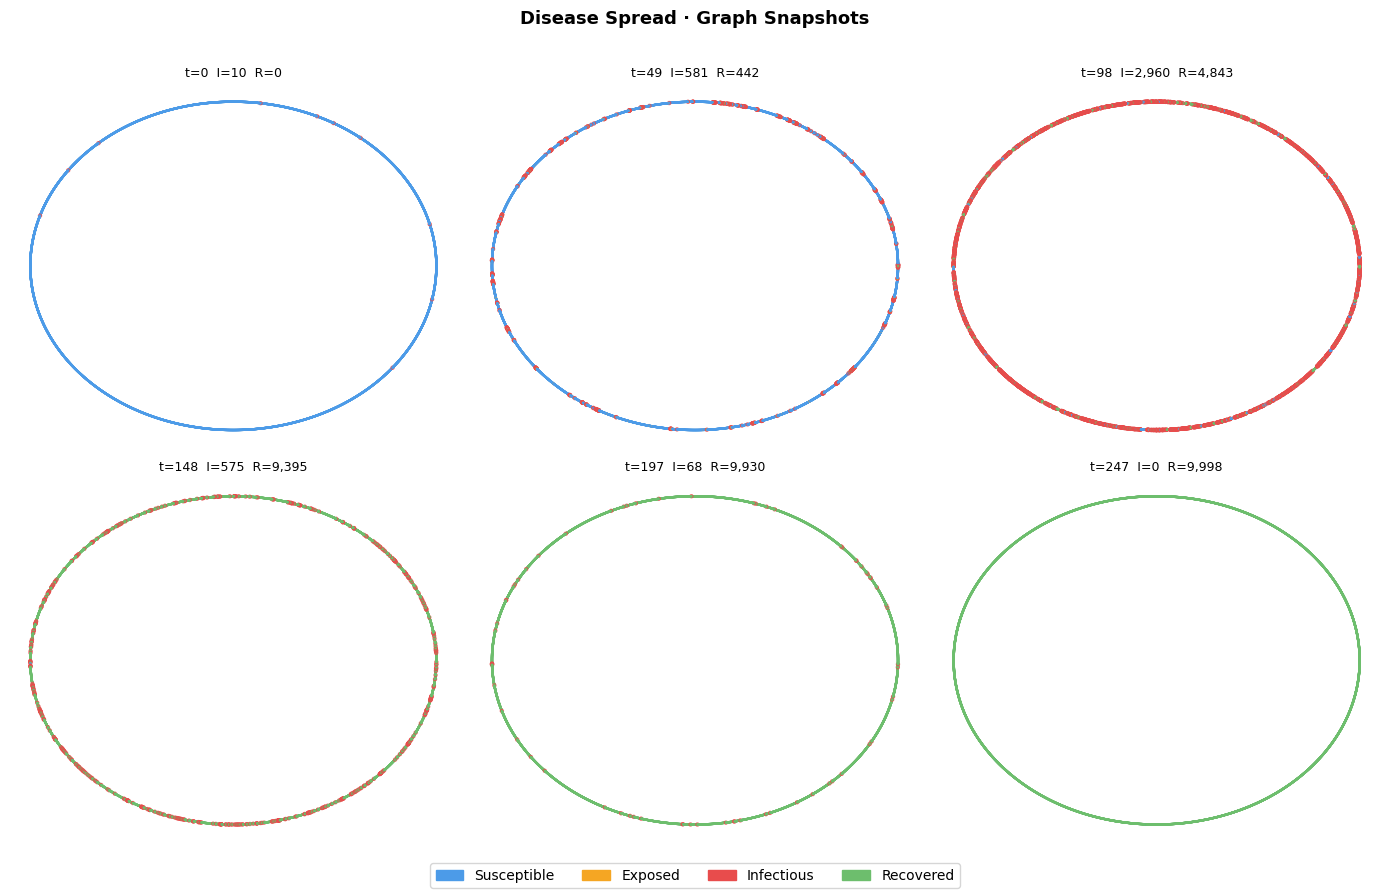

In [21]:
print('Computing layout…')
pos = nx.circular_layout(G)
xs  = np.array([pos[n][0] for n in G.nodes()])
ys  = np.array([pos[n][1] for n in G.nodes()])
 
snap_times = np.linspace(0, T_end, 6, dtype=int)
fig, axes  = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Disease Spread · Graph Snapshots', fontsize=13, fontweight='bold')
 
for ax, t in zip(axes.flat, snap_times):
    st = history[t]
    ax.scatter(xs, ys, c=[COLORS[s] for s in st],
               s=np.where(st == I, 10, 3), alpha=.8, linewidths=0)
    ax.set_title(f't={t}  I={counts["I"][t]:,}  R={counts["R"][t]:,}', fontsize=9)
    ax.axis('off')
 
patches = [mpatches.Patch(color=COLORS[v], label=LABELS[v]) for v in [S, E, I, R]]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10)
plt.tight_layout(rect=[0, .04, 1, .97])
plt.savefig(f'{OUTPUT_DIR}/seir_snapshots.png', dpi=120, bbox_inches='tight')
plt.show()